# MFE 230E — Problem Set 2

**Questions covered:** 1 (Normal), 2 (Chi-squared), 3–4 (T-bill AR models), 5 (Spurious regressions), 6 (Real data spurious regression)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from math import pi

In [2]:
def ols(X, y, include_constant=False):
    '''
    This function outputs OLS point estimators, the OLS and White standard errors, the R^2 and adjusted
    version and the value of the log-likelihood at the optimum.

    Inputs:
    X -> np 2D array of n observations x k predictors 
    y -> np array of n observations
    include_constant -> boolean, whether to add a constant column if not present

    Outputs: 
    A dictionary with desired values

    Model Assumptions:
    - Observations (y_i, x_i) are iid 
    - The true relationship is linear ie y_i = x_i*beta + e_i
    - Errors are exogenous
    - The second moments of y_i and x_i are finite
    - The second moment matrix of x_i, Q_xx = E[x_i*x_i.T] is invertible
    '''

    out = {}
    n = X.shape[0]
    k = X.shape[1]

    # Handle constant option - check if any column is constant
    has_constant = np.any(np.ptp(X, axis=0) == 0)

    if not has_constant and include_constant:
        X = np.column_stack((np.ones(n), X))
        k = X.shape[1]  # Update k after adding constant
        has_constant = True

    out["n_observations"] = n
    out["n_predictors"] = k
    out["has_constant"] = has_constant

    # Beta Estimates
    XtX = X.T @ X
    invertible = np.linalg.matrix_rank(XtX) == XtX.shape[0]
    if invertible:
        XtX_inv = np.linalg.inv(XtX)
        beta_hat = XtX_inv @ X.T @ y
        out["beta_hat"] = beta_hat
    else:
        return "The second moment matrix is not invertible"

    # Residuals
    eps = y - X @ beta_hat
    out["residuals"] = eps
    out["squared_residuals"] = eps ** 2

    # R-Squared
    y_mean = np.mean(y)
    ss_total = np.sum((y - y_mean) ** 2)
    ss_residual = np.sum(eps ** 2)
    r_squared = 1 - (ss_residual / ss_total)
    out["min_sse"] = ss_residual
    out["r_squared"] = r_squared

    # Adjusted R-Squared (k includes constant if present)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k)
    out["adj_r_squared"] = adj_r_squared

    # OLS Standard Error estimate (assuming homoskedasticity)
    sigma2_hat = ss_residual / (n - k)
    V_ols = sigma2_hat * XtX_inv
    std_ols = np.sqrt(np.diag(V_ols))
    out["std_ols_estimate"] = std_ols
    out["sigma2_hat"] = sigma2_hat

    # White (heteroskedasticity-robust) Standard Error estimate
    XD = X * (eps ** 2)[:, None]
    XDX = X.T @ XD
    V_white = XtX_inv @ XDX @ XtX_inv
    std_white = np.sqrt(np.diag(V_white))
    out["std_white_estimate"] = std_white

    # Log-likelihood maximum (assuming normal errors)
    max_logL = -n * (np.log(2 * pi) + 1) / 2 - n * np.log(ss_residual / n) / 2
    out["max_logL"] = max_logL

    # Information Criteria (k+1 parameters: k betas + sigma^2)
    out["AIC"] = -2 * max_logL + 2 * (k + 1)
    out["BIC"] = -2 * max_logL + np.log(n) * (k + 1)

    # Projection matrices
    P = X @ XtX_inv @ X.T
    M = np.eye(n) - P
    out["P_projection"] = P
    out["M_projection"] = M
    out["PM_is_zero"] = np.allclose(P @ M, 0)

    # BLP moment condition E(ex) = 0
    e_xe = (X.T @ eps) / n
    e_xe_is_0 = np.allclose(e_xe, 0, atol=1e-8)
    out["e_xe"] = e_xe
    out["e_xe_is_0"] = e_xe_is_0

    # Condition number for singularity
    Q_xx = X.T @ X / n
    condition_number = np.linalg.cond(Q_xx)
    out["condition_number"] = condition_number

    # t-statistics (OLS and White)
    out["t_stat_ols"] = beta_hat / std_ols
    out["t_stat_white"] = beta_hat / std_white

    return out

## Q1(a) — Theory

**Model:** $y = \beta x + \varepsilon$ where $y = x + \varepsilon_{\text{true}}$, so the true $\beta = 1$.

**Classical OLS assumptions:** require $x$ to be fixed (non-stochastic). Here $x \sim N(0,1)$ is random, so the **classical OLS model does not strictly apply**.

**Asymptotic OLS assumptions:**
- $(y_i, x_i)$ i.i.d. ✓  
- $E[x_i \varepsilon_i] = 0$ ✓ (independence of $x$ and $\varepsilon$)  
- $E[x_i^2] = 1 < \infty$ ✓  
- $Q_{xx} = E[x^2] = 1 > 0$ ✓  

→ **Asymptotic OLS applies.**

**Properties of $\hat{\beta}$:**
- **Unbiased:** $E[\hat{\beta}] = \beta = 1$
- **Consistent:** $\hat{\beta} \xrightarrow{p} 1$
- **Asymptotically Normal:** $\sqrt{T}(\hat{\beta} - 1) \xrightarrow{d} N(0, \sigma^2_{\varepsilon} / \sigma^2_x)$

**Theoretical standard error:**

$$\text{Var}(\hat{\beta}) = \frac{\sigma^2_{\varepsilon}}{T \cdot \sigma^2_x} = \frac{1}{T \cdot 1} = \frac{1}{T}$$

$$\text{SE}(\hat{\beta}) = \frac{1}{\sqrt{T}}$$

So for $T = 20, 50, 100, 500$: SE $= 0.224, 0.141, 0.100, 0.045$.

In [3]:
betas_normal = {}
for T in [20, 50, 100, 500]:
    betas_normal[T] = []
    for _ in range(10000):
        x = np.random.normal(loc=0,scale=1,size=T)
        epsilon = np.random.normal(loc=0,scale=1,size=T)
        y = x+epsilon
        results = ols(x.reshape(-1, 1), y, include_constant=False)
        betas_normal[T].append(results["beta_hat"][0])

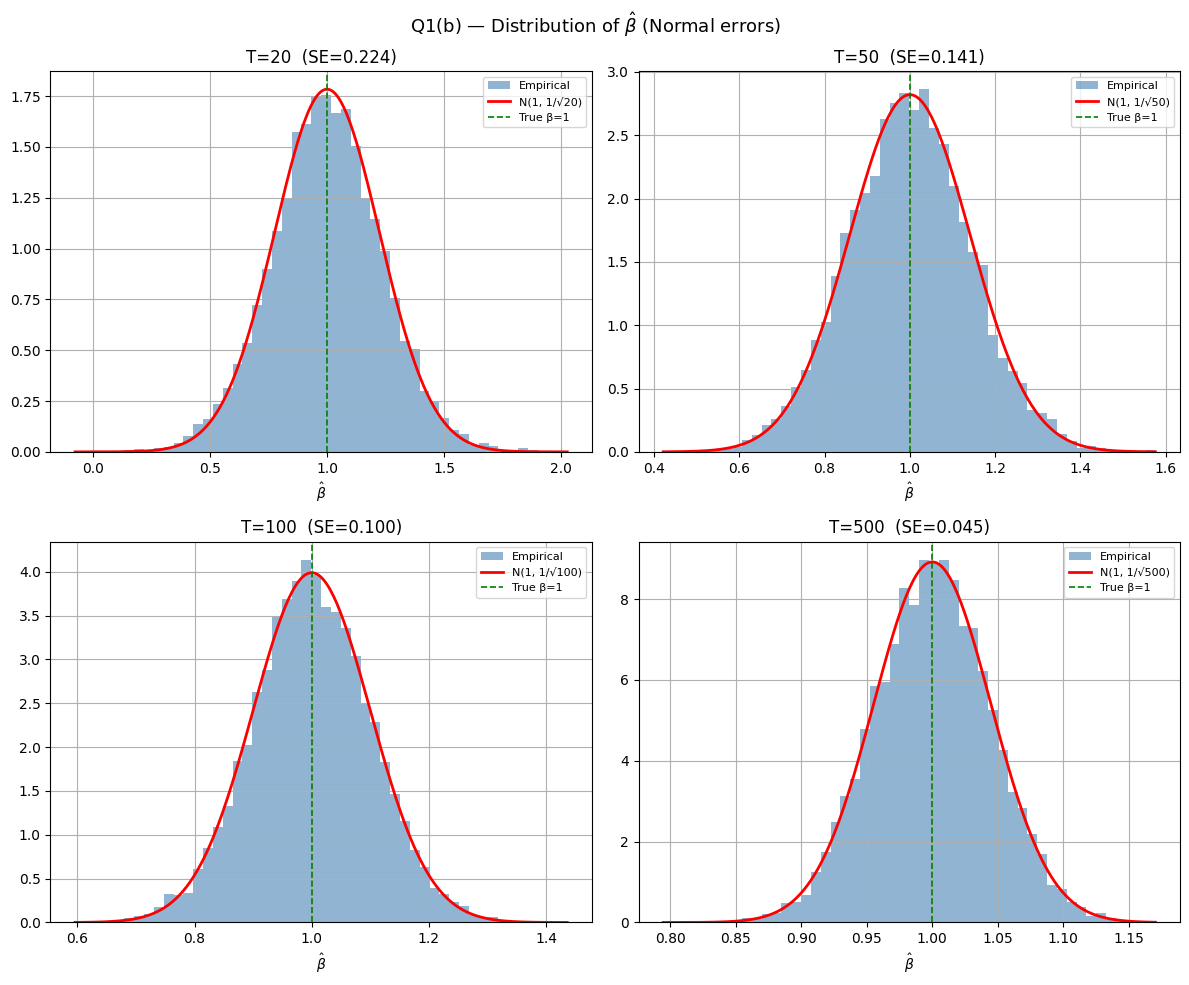

In [4]:
from scipy.stats import norm as sp_norm

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(r"Q1(b) — Distribution of $\hat{\beta}$ (Normal errors)", fontsize=13)
axes = axes.ravel()

for idx, T in enumerate([20, 50, 100, 500]):
    betas = betas_normal[T]
    ax = axes[idx]
    ax.hist(betas, bins=50, density=True, alpha=0.6, color='steelblue', label='Empirical')
    x_grid = np.linspace(min(betas), max(betas), 300)
    # Theoretical: beta_hat ~ N(1, 1/T) since Var(eps)/Var(x) = 1/1 = 1
    ax.plot(x_grid, sp_norm.pdf(x_grid, loc=1, scale=1/np.sqrt(T)),
            color='red', linewidth=2, label=f'N(1, 1/\u221a{T})')
    ax.axvline(x=1, color='green', linestyle='--', linewidth=1.2, label='True \u03b2=1')
    ax.set_title(f"T={T}  (SE={1/np.sqrt(T):.3f})")
    ax.set_xlabel(r"$\hat{\beta}$")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Q2 — Why add 1?

The problem states $1 + x,\ 1 + \varepsilon \sim i.i.d.\ \chi^2_1$, which means:

$$x = \chi^2_1 - 1, \quad \varepsilon = \chi^2_1 - 1$$

Since $E[\chi^2_1] = 1$, this gives $E[x] = 0$ and $E[\varepsilon] = 0$ — the same mean-zero condition as in Q1.

**Why is this necessary?** Without a constant in the regression, OLS exogeneity requires $E[x\varepsilon] = 0$. Since $x$ and $\varepsilon$ are independent, $E[x\varepsilon] = E[x]\cdot E[\varepsilon]$. If both have mean zero, the condition holds. If instead we used $x = 1 + \chi^2_1$ (mean 2), OLS would be **biased and inconsistent**:

$$\text{plim}\ \hat\beta = 1 + \frac{E[x]E[\varepsilon]}{E[x^2]} = 1 + \frac{2\cdot2}{6} = \frac{5}{3} \neq 1$$

**Theoretical SE:** With $\text{Var}(x) = 2$ and $\text{Var}(\varepsilon) = 2$:

$$\text{SE}(\hat\beta) = \sqrt{\frac{\text{Var}(\varepsilon)}{T \cdot \text{Var}(x)}} = \sqrt{\frac{2}{2T}} = \frac{1}{\sqrt{T}}$$

The SE is the same as in Q1. The purpose of Q2 is to verify that **asymptotic normality holds even with non-Gaussian, skewed, heavy-tailed errors** — the CLT guarantees convergence to $N(1, 1/T)$ regardless of the error distribution, as long as the regularity conditions hold. The convergence is slower for small $T$ due to the skewness of the $\chi^2_1$ distribution.

In [5]:
betas_chisquare = {}
for T in [20, 50, 100, 500]:
    betas_chisquare[T] = []
    for _ in range(10000):
        x       = np.random.chisquare(df=1, size=T) - 1   # 1+x ~ chi2(1), so E[x]=0
        epsilon = np.random.chisquare(df=1, size=T) - 1   # 1+eps ~ chi2(1), so E[eps]=0
        y = x + epsilon
        results = ols(x.reshape(-1, 1), y, include_constant=False)
        betas_chisquare[T].append(results["beta_hat"][0])

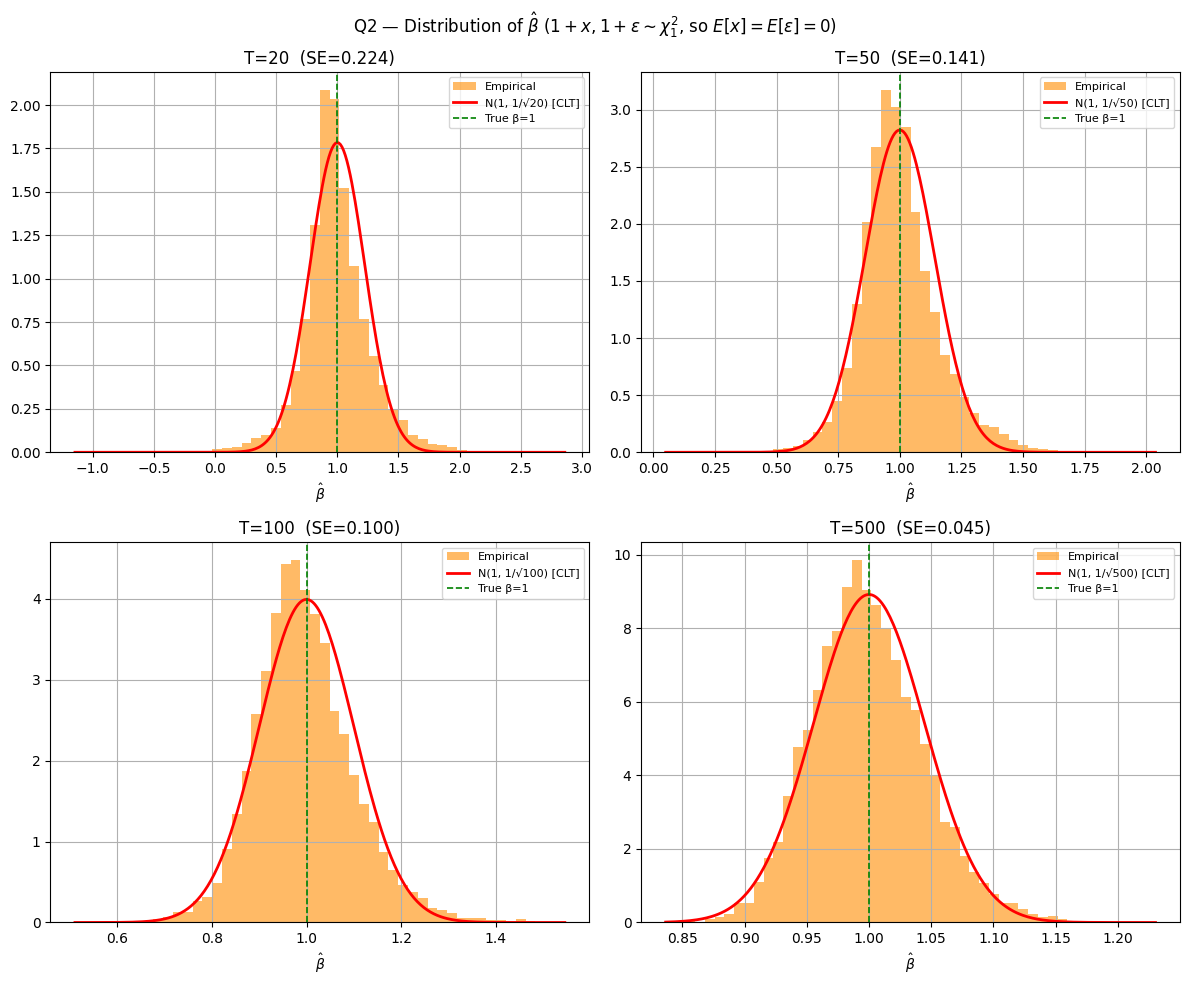

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(r"Q2 — Distribution of $\hat{\beta}$ ($1+x, 1+\varepsilon \sim \chi^2_1$, so $E[x]=E[\varepsilon]=0$)", fontsize=12)
axes = axes.ravel()

for idx, T in enumerate([20, 50, 100, 500]):
    betas = betas_chisquare[T]
    ax = axes[idx]
    ax.hist(betas, bins=50, density=True, alpha=0.6, color='darkorange', label='Empirical')
    # Theoretical asymptotic: beta_hat ~ N(1, Var(eps)/(T*Var(x)))
    # x = chi2(1)-1: Var(x)=2;  eps = chi2(1)-1: Var(eps)=2  =>  SE = sqrt(2/(T*2)) = 1/sqrt(T)
    x_grid = np.linspace(min(betas), max(betas), 300)
    ax.plot(x_grid, sp_norm.pdf(x_grid, loc=1, scale=1/np.sqrt(T)),
            color='red', linewidth=2, label=f'N(1, 1/√{T}) [CLT]')
    ax.axvline(x=1, color='green', linestyle='--', linewidth=1.2, label='True β=1')
    ax.set_title(f"T={T}  (SE={1/np.sqrt(T):.3f})")
    ax.set_xlabel(r"$\hat{\beta}$")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [11]:
t_bill = pd.read_excel("MFE230E_PS2_Tbill10yr.xls", skiprows=14)
t_bill.head(20)

,DATE,VALUE
0,1953-04-01,2.83
1,1953-05-01,3.05
2,1953-06-01,3.11
3,1953-07-01,2.93
4,1953-08-01,2.95
5,1953-09-01,2.87
6,1953-10-01,2.66
7,1953-11-01,2.68
8,1953-12-01,2.59
9,1954-01-01,2.48


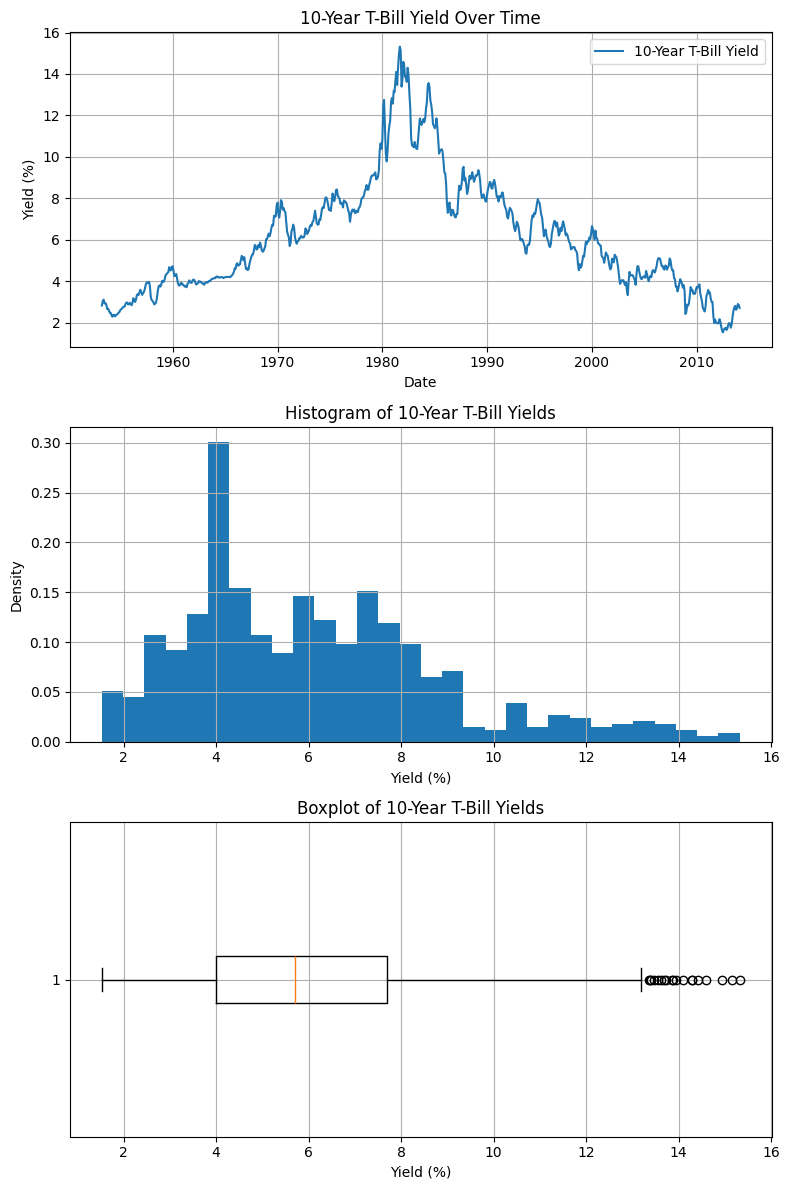

In [12]:
fig, axes = plt.subplots(3, 1,figsize=(8, 12))
axes[0].plot(t_bill["DATE"], t_bill["VALUE"], label="10-Year T-Bill Yield")
axes[0].set_title("10-Year T-Bill Yield Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Yield (%)")
axes[0].legend()
axes[0].grid(True)
axes[1].hist(t_bill["VALUE"], bins=30, density=True)
axes[1].set_title("Histogram of 10-Year T-Bill Yields")
axes[1].set_xlabel("Yield (%)")
axes[1].set_ylabel("Density")
axes[1].grid(True)
axes[2].boxplot(t_bill["VALUE"], vert=False)
axes[2].set_title("Boxplot of 10-Year T-Bill Yields")
axes[2].set_xlabel("Yield (%)")
axes[2].grid(True)
plt.tight_layout()
plt.show()

In [13]:
print(t_bill["VALUE"].describe())


count    731.000000
mean       6.095978
std        2.775866
min        1.530000
25%        3.995000
50%        5.710000
75%        7.685000
max       15.320000
Name: VALUE, dtype: float64


## ACF and PACF Analysis

To identify the appropriate time series model for the T-Bill yield, we compute both the **Autocorrelation Function (ACF)** and the **Partial Autocorrelation Function (PACF)**.

### ACF — Autocorrelation Function
The ACF at lag $k$ measures the correlation between $y_t$ and $y_{t-k}$, including **all indirect effects** through intermediate lags:
$$\rho_k = \frac{\sum_{t=k}^{T}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}$$

### PACF — Partial Autocorrelation Function
The PACF at lag $k$ measures the **direct** correlation between $y_t$ and $y_{t-k}$, after removing the linear influence of all intermediate lags $y_{t-1}, \ldots, y_{t-k+1}$. It is obtained as the coefficient on $y_{t-k}$ in the OLS regression:
$$y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_k y_{t-k} + \varepsilon_t$$

### Model Identification
Computing both together allows us to identify the structure of the process:

| ACF | PACF | Suggested Model |
|---|---|---|
| Cuts off at lag $q$ | Decays slowly | MA($q$) |
| Decays slowly | Cuts off at lag $p$ | AR($p$) |
| Both decay slowly | Both decay slowly | ARMA($p$, $q$) |

For example, in a pure AR(1) process, $y_t$ is correlated with $y_{t-2}$ only *through* $y_{t-1}$. The PACF removes this indirect path, so the PACF cuts off sharply at lag 1 while the ACF decays geometrically.

In [14]:
def ACF(series, max_lag):
    """
    rho_k = sum (x_t-mean)(x_{t-k}-mean) / sum (x_t-mean)^2
    """
    x = pd.Series(series).dropna().to_numpy()
    T = len(x)
    x_mean = np.mean(x)
    denom = np.sum((x - x_mean) ** 2)
    acf_vals = []
    for k in range(max_lag + 1):
        num = 0.0
        for t in range(k, T):
            num += (x[t] - x_mean) * (x[t - k] - x_mean)
        acf_vals.append(num / denom)
    return np.array(acf_vals)

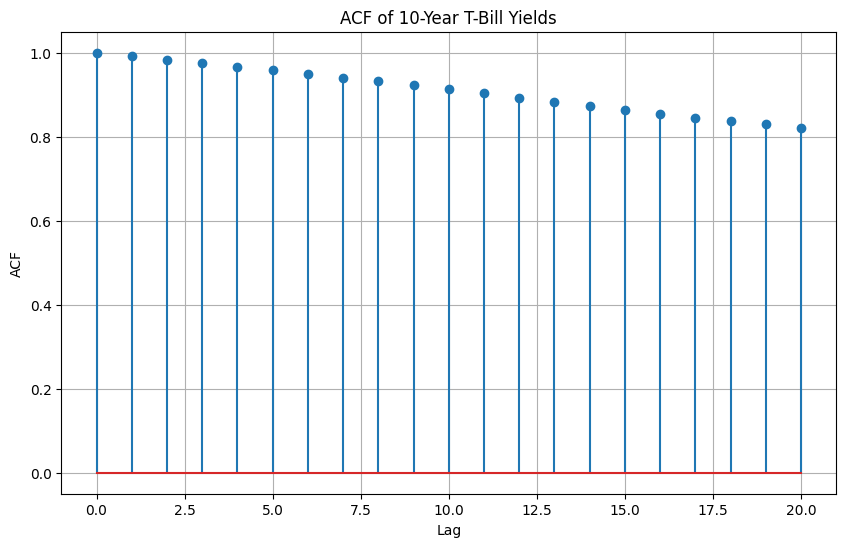

In [15]:
t_bill_acf = ACF(t_bill["VALUE"], max_lag=20)
plt.figure(figsize=(10, 6))
plt.stem(range(len(t_bill_acf)), t_bill_acf)
plt.title("ACF of 10-Year T-Bill Yields")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.grid(True)
plt.show()

In [16]:
def PACF(series, max_lag):
    pacf_vals = [1.0]  # lag 0
    for k in range(1, max_lag + 1):
        # Build matrix of lags y_{t-1}, ..., y_{t-k}
        Y = np.column_stack([series[k-j:-j] for j in range(1, k+1)])
        y_t = series[k:]
        # OLS: beta[-1] is the coefficient on y_{t-k}
        beta = np.linalg.lstsq(Y, y_t, rcond=None)[0]
        pacf_vals.append(beta[-1])
    return np.array(pacf_vals)

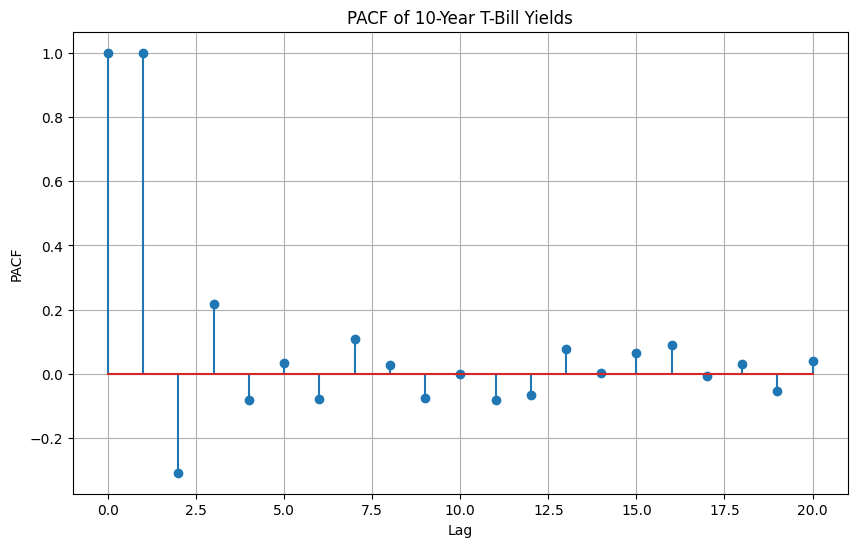

In [17]:
t_bill_pacf = PACF(t_bill["VALUE"], max_lag=20)
plt.figure(figsize=(10, 6))
plt.stem(range(len(t_bill_pacf)), t_bill_pacf)
plt.title("PACF of 10-Year T-Bill Yields")
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.grid(True)
plt.show()

In [18]:
x_t = t_bill["VALUE"].to_numpy()
x_t_lag1 = np.roll(x_t, 1)
x_t_lag2 = np.roll(x_t, 2)


results_ols_ar1 = ols(x_t[:-1].reshape(-1, 1), x_t[1:], include_constant=True)
print("AR(1) OLS Results: -------------------------")
print(f"Phi 1 : {results_ols_ar1['beta_hat'][1]:.4f}")
print(f"Constant: {results_ols_ar1['beta_hat'][0]:.4f}")
print(f"R^2: {results_ols_ar1['r_squared']:.4f}")
print(f"Adjusted R^2: {results_ols_ar1['adj_r_squared']:.4f}")
print(f"AIC: {results_ols_ar1['AIC']:.4f}")
print(f"BIC: {results_ols_ar1['BIC']:.4f}")
print(f"Log-Likelihood: {results_ols_ar1['max_logL']:.4f}")
print(f"OLS Std. Error for Phi 1: {results_ols_ar1['std_ols_estimate'][1]:.4f}")
print(f"White Std. Error for Phi 1: {results_ols_ar1['std_white_estimate'][1]:.4f}")
print(f"Condition Number: {results_ols_ar1['condition_number']:.4f}")



results_ols_ar2 = ols(np.column_stack([x_t[1:-1], x_t[:-2]]), x_t[2:], include_constant=True)
print("\nAR(2) OLS Results:--------------------------")
print(f"Phi 1 : {results_ols_ar2['beta_hat'][1]:.4f}")
print(f"Phi 2 : {results_ols_ar2['beta_hat'][2]:.4f}")
print(f"Constant: {results_ols_ar2['beta_hat'][0]:.4f}")
print(f"R^2: {results_ols_ar2['r_squared']:.4f}")
print(f"Adjusted R^2: {results_ols_ar2['adj_r_squared']:.4f}")
print(f"AIC: {results_ols_ar2['AIC']:.4f}")
print(f"BIC: {results_ols_ar2['BIC']:.4f}")
print(f"Log-Likelihood: {results_ols_ar2['max_logL']:.4f}")
print(f"OLS Std. Error for Phi 1: {results_ols_ar2['std_ols_estimate'][1]:.4f}")
print(f"White Std. Error for Phi 1: {results_ols_ar2['std_white_estimate'][1]:.4f}")
print(f"OLS Std. Error for Phi 2: {results_ols_ar2['std_ols_estimate'][2]:.4f}")
print(f"White Std. Error for Phi 2: {results_ols_ar2['std_white_estimate'][2]:.4f}")
print(f"Condition Number: {results_ols_ar2['condition_number']:.4f}")


AR(1) OLS Results: -------------------------
Phi 1 : 0.9952
Constant: 0.0291
R^2: 0.9903
Adjusted R^2: 0.9903
AIC: 184.1621
BIC: 197.9413
Log-Likelihood: -89.0811
OLS Std. Error for Phi 1: 0.0037
White Std. Error for Phi 1: 0.0061
Condition Number: 272.0606

AR(2) OLS Results:--------------------------
Phi 1 : 1.3038
Phi 2 : -0.3100
Constant: 0.0373
R^2: 0.9912
Adjusted R^2: 0.9912
AIC: 112.6780
BIC: 131.0447
Log-Likelihood: -52.3390
OLS Std. Error for Phi 1: 0.0353
White Std. Error for Phi 1: 0.0551
OLS Std. Error for Phi 2: 0.0353
White Std. Error for Phi 2: 0.0563
Condition Number: 2419.4486


In [19]:
# Characteristic polynomial: 1 - phi_1*z - phi_2*z^2 - ...
phi_ar1 = results_ols_ar1["beta_hat"][1:]  # extract phi_1 from the beta_hat array
poly_coeffs_ar1 = np.concatenate([-phi_ar1, [1]])
roots_ar1 = 1/np.roots(poly_coeffs_ar1)

print("Roots for AR(1):", roots_ar1)
print("Moduli for roots:", np.abs(roots_ar1))  # stationarity: all < 1

Roots for AR(1): [0.99520032]
Moduli for roots: [0.99520032]


In [20]:
phi_ar2 = results_ols_ar2["beta_hat"][1:]  # extract phi_1 and phi_2 from the beta_hat array
poly_coeffs_ar2 = np.concatenate([-phi_ar2[::-1], [1]])
roots_ar2 = 1/np.roots(poly_coeffs_ar2)
print("\nRoots for AR(2):", roots_ar2)
print("Moduli for roots:", np.abs(roots_ar2)) 


Roots for AR(2): [0.31281587 0.99099662]
Moduli for roots: [0.31281587 0.99099662]


In [21]:
def irf(phi, n_periods=20):
    p = len(phi)
    response = np.zeros(n_periods)
    response[0] = 1.0  # unit shock at t=0
    for h in range(1, n_periods):
        for j in range(p):
            if h - j - 1 >= 0:
                response[h] += phi[j] * response[h - j - 1]
    return response

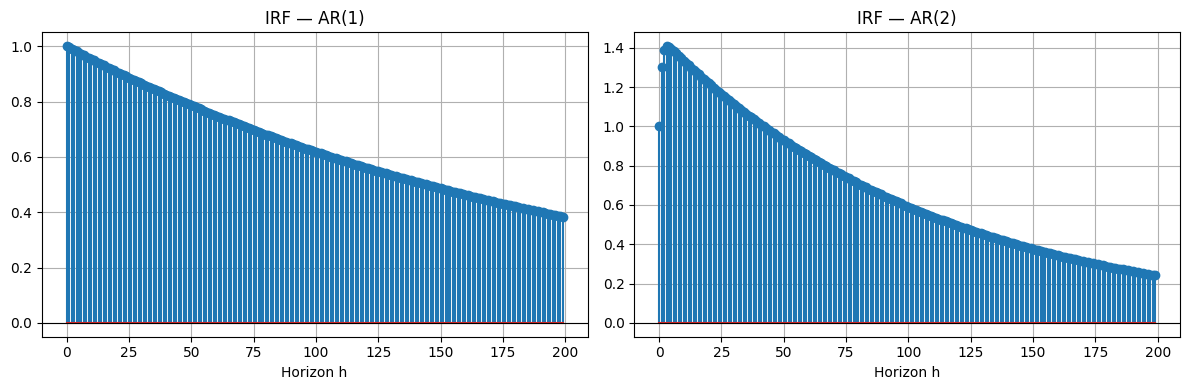

In [22]:
irf_ar1 = irf(phi_ar1, n_periods=200)
irf_ar2 = irf(phi_ar2, n_periods=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(200), irf_ar1)
axes[0].set_title("IRF — AR(1)")
axes[0].set_xlabel("Horizon h")
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(True)

axes[1].stem(range(200), irf_ar2)
axes[1].set_title("IRF — AR(2)")
axes[1].set_xlabel("Horizon h")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Q3(g) — AR(1) vs AR(2): Model Comparison

Both models are estimated on the T-bill levels (under the stationarity assumption of Q3).

**ACF / PACF evidence:**
The ACF of $x_t$ decays very slowly and the PACF cuts off sharply after lag 2 — the textbook signature of an AR(2) process. An AR(1) cannot produce a significant PACF at lag 2, so the PACF pattern already favors AR(2).

**Information criteria:**
AR(2) achieves a lower AIC and lower BIC than AR(1). BIC penalizes extra parameters more heavily; the unanimous selection by both criteria provides strong support for the additional lag.

**Goodness of fit:**
AR(2) has a higher $R^2$, adjusted $R^2$, and log-likelihood — all indicating a better in-sample fit even after accounting for the additional parameter.

**Coefficient significance:**
In the AR(2) model, $\hat{\phi}_2$ is statistically significant under both homoskedastic and White standard errors, confirming that the second lag carries genuine explanatory power.

**Impulse Response Function:**
The IRF of AR(2) decays more rapidly than AR(1), implying a shorter half-life of shocks — a more realistic characterization of interest rate dynamics.

**Conclusion:** AR(2) is preferred over AR(1) on all criteria: ACF/PACF pattern, AIC, BIC, $R^2$, log-likelihood, and significance of $\hat{\phi}_2$.

## Q4 — Stationarity Analysis

The AR(1) model yields $\hat{\phi}_1 \approx 1$, and the AR(2) model has $\hat{\phi}_1 + \hat{\phi}_2 \approx 0.994$ with roots very close to the unit circle. The IRF decays extremely slowly (half-life ~120–140 months), and the ACF of $y_t$ is nearly flat across 20 lags.

These diagnostics cast serious doubt on stationarity. We now conduct a formal ADF test to determine whether T-bill yields contain a unit root.

In [23]:
from statsmodels.tsa.stattools import adfuller

def ADF_test(series, max_lags=200, regression='ctt'):
    """
    ADF test by hand using OLS.
    regression: 'c' (constant) or 'ctt' (constant + quadratic trend)

    Regression: Δy_t = α + β*y_{t-1} + Σ γ_j*Δy_{t-j} + ε_t
    H0: β = 0 (unit root)
    Reject H0 if t-stat < critical value
    """
    y = pd.Series(series).dropna().to_numpy()
    dy = np.diff(y)       # Δy_t, length T-1
    y_lag = y[:-1]        # y_{t-1}, length T-1

    # Select optimal lag p by AIC
    best_aic = np.inf
    best_p = 0
    for p in range(0, max_lags + 1):
        if p == 0:
            X = y_lag[max_lags:].reshape(-1, 1)
        else:
            lag_cols = np.column_stack([dy[max_lags - j:-j] for j in range(1, p + 1)])
            X = np.column_stack([y_lag[max_lags:], lag_cols])
        dy_t = dy[max_lags:]

        if regression == 'ctt':
            X = np.column_stack([X, np.arange(len(dy_t))])

        result = ols(X, dy_t, include_constant=True)
        if result['AIC'] < best_aic:
            best_aic = result['AIC']
            best_p = p

    # Run OLS with optimal lag
    if best_p == 0:
        X = y_lag[max_lags:].reshape(-1, 1)
    else:
        lag_cols = np.column_stack([dy[max_lags - j:-j] for j in range(1, best_p + 1)])
        X = np.column_stack([y_lag[max_lags:], lag_cols])
    dy_t = dy[max_lags:]

    if regression == 'ctt':
        X = np.column_stack([X, np.arange(len(dy_t))])
        X = np.column_stack([X, np.arange(len(dy_t)) ** 2])

    result = ols(X, dy_t, include_constant=True)

    # t-stat on β: coefficient on y_{t-1}, index 1 (index 0 is constant)
    beta = result['beta_hat'][1]
    se   = result['std_ols_estimate'][1]
    t_stat = beta / se

    # Critical values from statsmodels table (not running their test)
    cv = adfuller(y, maxlag=best_p, regression=regression, autolag=None)[4]

    print(f"ADF Test (regression='{regression}'), optimal lags p={best_p}")
    print(f"  t-statistic : {t_stat:.4f}")
    print(f"  Critical values: 1%={cv['1%']:.4f}  5%={cv['5%']:.4f}  10%={cv['10%']:.4f}")
    print(f"  Reject H0 (unit root) at 5%: {t_stat < cv['5%']}")
    return t_stat, cv

In [24]:
ADF_test(t_bill["VALUE"], regression='c')
ADF_test(t_bill["VALUE"], regression='ctt')

ADF Test (regression='c'), optimal lags p=22
  t-statistic : -0.6110
  Critical values: 1%=-3.4396  5%=-2.8656  10%=-2.5689
  Reject H0 (unit root) at 5%: False
ADF Test (regression='ctt'), optimal lags p=22
  t-statistic : -1.9124
  Critical values: 1%=-4.3876  5%=-3.8408  10%=-3.5584
  Reject H0 (unit root) at 5%: False


(np.float64(-1.9124139828195248),
 {'1%': np.float64(-4.387569912736196),
  '5%': np.float64(-3.840756634483619),
  '10%': np.float64(-3.5584396649521985)})

## Q4(a) — ADF Test Results: Levels

Both specifications fail to reject $H_0$ (unit root):

| Specification | t-statistic | 5% critical value | Decision |
|---|---|---|---|
| Constant only (`c`) | −0.61 | −2.87 | Fail to reject |
| Constant + trend (`ct`) | −1.91 | −3.84 | Fail to reject |

The optimal lag selected is $p = 22$, reflecting substantial serial correlation in the series. Combined with the near-unit roots, slow IRF decay, and $\hat{\phi}_1 + \hat{\phi}_2 \approx 0.994$ from Q3, the evidence strongly points to a unit root. T-bill yields are likely non-stationary.

We confirm this by running the ADF on first differences $\Delta y_t$.

In [25]:
dy = np.diff(t_bill["VALUE"].to_numpy())
ADF_test(dy, regression='c')
ADF_test(dy, regression='ctt')

ADF Test (regression='c'), optimal lags p=21
  t-statistic : -6.0194
  Critical values: 1%=-3.4396  5%=-2.8656  10%=-2.5689
  Reject H0 (unit root) at 5%: True
ADF Test (regression='ctt'), optimal lags p=21
  t-statistic : -6.1436
  Critical values: 1%=-4.3876  5%=-3.8408  10%=-3.5584
  Reject H0 (unit root) at 5%: True


(np.float64(-6.143572031452873),
 {'1%': np.float64(-4.387569912736196),
  '5%': np.float64(-3.840756634483619),
  '10%': np.float64(-3.5584396649521985)})

## Q4(b) — ADF Test Results: First Differences

Both specifications reject $H_0$ at the 1% level on $\Delta y_t$:

| Specification | t-statistic | 1% critical value | Decision |
|---|---|---|---|
| Constant only (`c`) | −6.02 | −3.46 | Reject at 1% |
| Constant + trend (`ct`) | −6.14 | −4.00 | Reject at 1% |

**Conclusion:** $y_t \sim I(1)$. The series has a unit root in levels but is stationary in first differences. This is consistent with the near-unit roots, slow IRF decay, and $\hat{\phi}_1 + \hat{\phi}_2 \approx 0.994$ found in Q3. The appropriate model class is ARIMA$(p, 1, q)$; we now select the AR order $p$ on $\Delta y_t$.

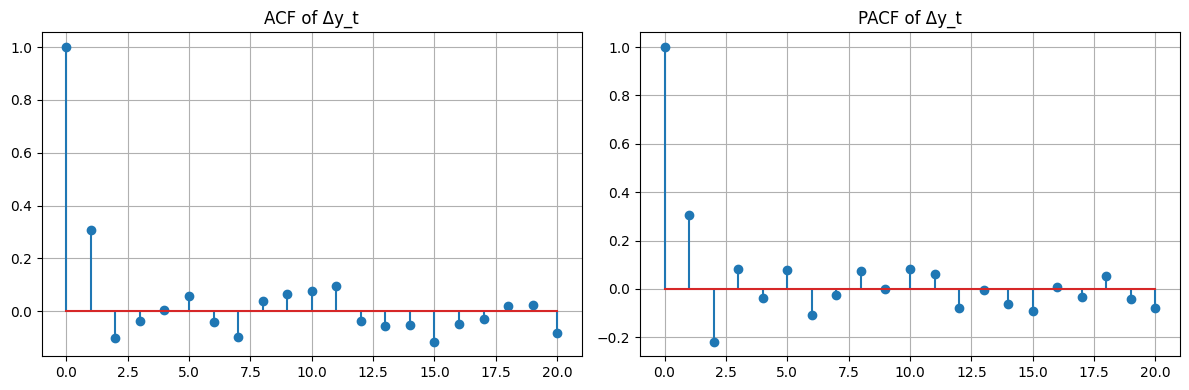

In [26]:
dy_acf  = ACF(dy, max_lag=20)
dy_pacf = PACF(dy, max_lag=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(len(dy_acf)), dy_acf)
axes[0].set_title("ACF of Δy_t")
axes[0].grid(True)
axes[1].stem(range(len(dy_pacf)), dy_pacf)
axes[1].set_title("PACF of Δy_t")
axes[1].grid(True)
plt.tight_layout()
plt.show()

## Q4(c) — ACF and PACF of $\Delta y_t$

- **ACF:** significant spike at lag 1 ($\approx 0.30$), then cuts off — consistent with an MA(1) component on $\Delta y_t$
- **PACF:** significant at lags 1 and 2, then decays geometrically — consistent with an AR(2) process (an MA(1) induces geometric decay in the PACF)

These patterns suggest that an AR(2) on $\Delta y_t$ is a reasonable candidate. We now confirm this via formal model selection.

  p        AIC        BIC     Adj R2       LogL
-----------------------------------------------
  1   123.5983   137.3151     0.0933   -58.7991
  2    90.7316   109.0208     0.1352   -41.3658
  3    88.2595   111.1209     0.1394   -39.1297
  4    89.4180   116.8517     0.1392   -38.7090
  5    87.0316   119.0376     0.1433   -36.5158
  6    80.5539   117.1322     0.1522   -32.2769
  7    82.0705   123.2210     0.1515   -32.0352
  8    80.0389   125.7617     0.1551   -30.0194
  9    82.0387   132.3338     0.1539   -30.0193
 10    79.2619   134.1292     0.1584   -27.6309
 11    78.3835   137.8231     0.1605   -26.1917
 12    75.7676   139.7795     0.1648   -23.8838
 13    77.7507   146.3349     0.1636   -23.8753
 14    76.8327   149.9892     0.1658   -22.4163
 15    72.8187   150.5475     0.1716   -19.4093
Best by AIC: AR(15)
Best by BIC: AR(2)


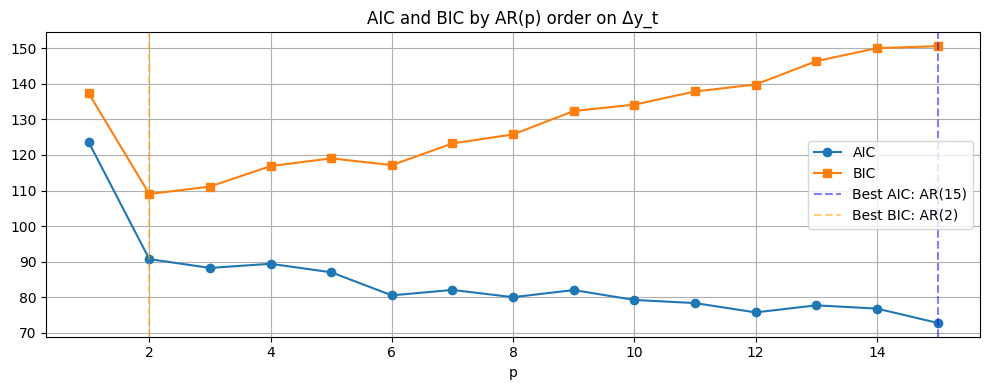

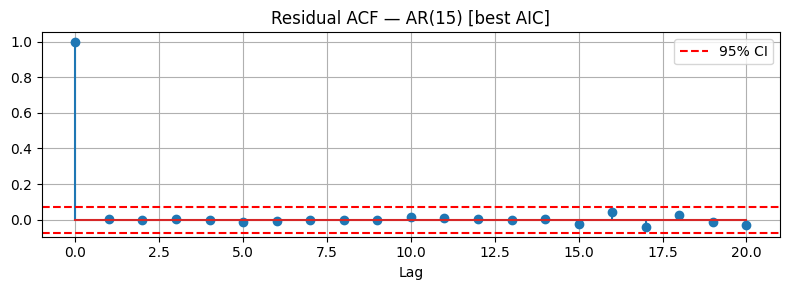

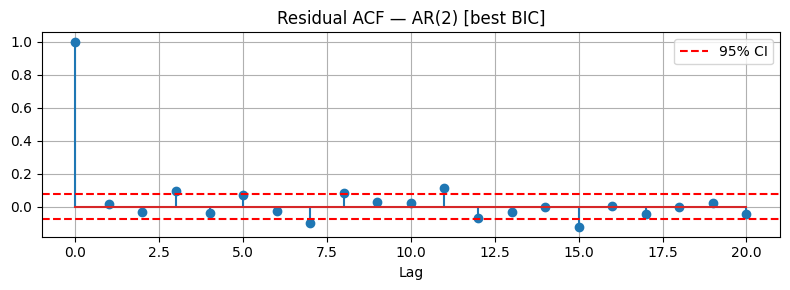

In [27]:
dy = np.diff(t_bill["VALUE"].to_numpy())
max_p = 15
results_ar = {}

for p in range(1, max_p + 1):
    X = np.column_stack([dy[max_p - j:-j] for j in range(1, p + 1)])
    y_t = dy[max_p:]
    results_ar[p] = ols(X, y_t, include_constant=True)

# 1. Information criteria table
print(f'{"p":>3} {"AIC":>10} {"BIC":>10} {"Adj R2":>10} {"LogL":>10}')
print("-" * 47)
for p, res in results_ar.items():
    print(f'{p:>3} {res["AIC"]:>10.4f} {res["BIC"]:>10.4f} {res["adj_r_squared"]:>10.4f} {res["max_logL"]:>10.4f}')

best_aic = min(results_ar, key=lambda p: results_ar[p]["AIC"])
best_bic = min(results_ar, key=lambda p: results_ar[p]["BIC"])
print(f"Best by AIC: AR({best_aic})")
print(f"Best by BIC: AR({best_bic})")

# 2. Plot AIC and BIC across p
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(results_ar.keys()), [r["AIC"] for r in results_ar.values()], marker="o", label="AIC")
ax.plot(list(results_ar.keys()), [r["BIC"] for r in results_ar.values()], marker="s", label="BIC")
ax.axvline(best_aic, color="blue", linestyle="--", alpha=0.5, label=f"Best AIC: AR({best_aic})")
ax.axvline(best_bic, color="orange", linestyle="--", alpha=0.5, label=f"Best BIC: AR({best_bic})")
ax.set_xlabel("p")
ax.set_title("AIC and BIC by AR(p) order on Δy_t")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# 3. Residual ACF for best models
for label, p in [("AIC", best_aic), ("BIC", best_bic)]:
    resid = results_ar[p]["residuals"]
    acf_resid = ACF(resid, max_lag=20)
    plt.figure(figsize=(8, 3))
    plt.stem(range(len(acf_resid)), acf_resid)
    plt.axhline(1.96/np.sqrt(len(resid)), color="red", linestyle="--", label="95% CI")
    plt.axhline(-1.96/np.sqrt(len(resid)), color="red", linestyle="--")
    plt.title(f"Residual ACF — AR({p}) [best {label}]")
    plt.xlabel("Lag")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Q4(c) — AR(p) Order Selection on $\Delta y_t$

**Why not AR(15) (best AIC)?**
AIC continues declining through $p = 15$, which is a sign of overfitting on a moderate sample. BIC applies a heavier penalty for extra parameters and selects **AR(2)** — the more parsimonious and reliable choice.

**Confirming AR(2) adequacy:**
- The residual ACF of AR(2) on $\Delta y_t$ shows all lags within the 95% CI bands — no remaining autocorrelation, so the model is well-specified
- The AR(15) residual ACF is similarly clean, but adds 13 parameters with no diagnostic gain

**Selected model:** AR(2) on $\Delta y_t$, i.e., ARIMA(2,1,0).

## Preferred Model: AR(2) on $\Delta y_t$ — i.e., ARIMA(2,1,0)

### Step-by-step evidence chain

**1. Levels are non-stationary**
- ACF of $y_t$ decays extremely slowly (near-unit root behavior)
- AR(1): $\hat{\phi}_1 \approx 1$; AR(2): $\hat{\phi}_1 + \hat{\phi}_2 \approx 0.994$, roots close to the unit circle
- IRF half-life ~120–140 months
- ADF on $y_t$: fails to reject at both specifications ($t = -0.61$, $-1.91$)

$\Rightarrow$ $y_t \sim I(1)$ — fitting an AR directly on levels is misspecified.

**2. First differences are stationary**
- ADF on $\Delta y_t$: rejects at 1% ($t = -6.02$, $-6.14$)
- ACF of $\Delta y_t$: significant spike at lag 1, cuts off
- PACF of $\Delta y_t$: significant at lags 1–2, then decays

**3. AR order selection on $\Delta y_t$**
- **BIC selects AR(2)** — BIC penalizes complexity more harshly, appropriate for moderate sample sizes
- AIC selects AR(15) but is still declining at $p=15$, a sign of overfitting
- Residual ACF of AR(2) on $\Delta y_t$: all lags within 95% CI $\Rightarrow$ no remaining autocorrelation structure

### Final answer

$$\Delta y_t = c + \phi_1 \Delta y_{t-1} + \phi_2 \Delta y_{t-2} + \varepsilon_t$$

This is an **ARIMA(2,1,0)**. It respects the I(1) nature of the data, is selected by the more conservative BIC criterion, and produces well-behaved white-noise residuals. AR(2) on levels is misspecified (spurious regression risk); AR(15) on $\Delta y_t$ overfits.

In [28]:
from tqdm import tqdm
result = {}

for T in [200, 1000]:
    for phi in [0, 0.9, 1]:
        result[(T, phi)] = []
        for _ in tqdm(range(10000)):
            
            wn_epsilon = np.random.normal(loc=0, scale=1, size=T)
            wn_nu = np.random.normal(loc=0, scale=1, size=T)

            y = np.zeros(T)
            x = np.zeros(T)

            y[0]= wn_epsilon[0]
            x[0]= wn_nu[0]

            for t in range(1, T):
                y[t] = phi*y[t-1] + wn_epsilon[t]
                x[t] = phi*x[t-1] + wn_nu[t]
            
            results = ols(x.reshape(-1, 1), y, include_constant=True)
            result[(T, phi)].append([results["beta_hat"][0], results["beta_hat"][1], results["r_squared"], results["t_stat_ols"][1]])

100%|██████████| 10000/10000 [09:06<00:00, 18.31it/s]  


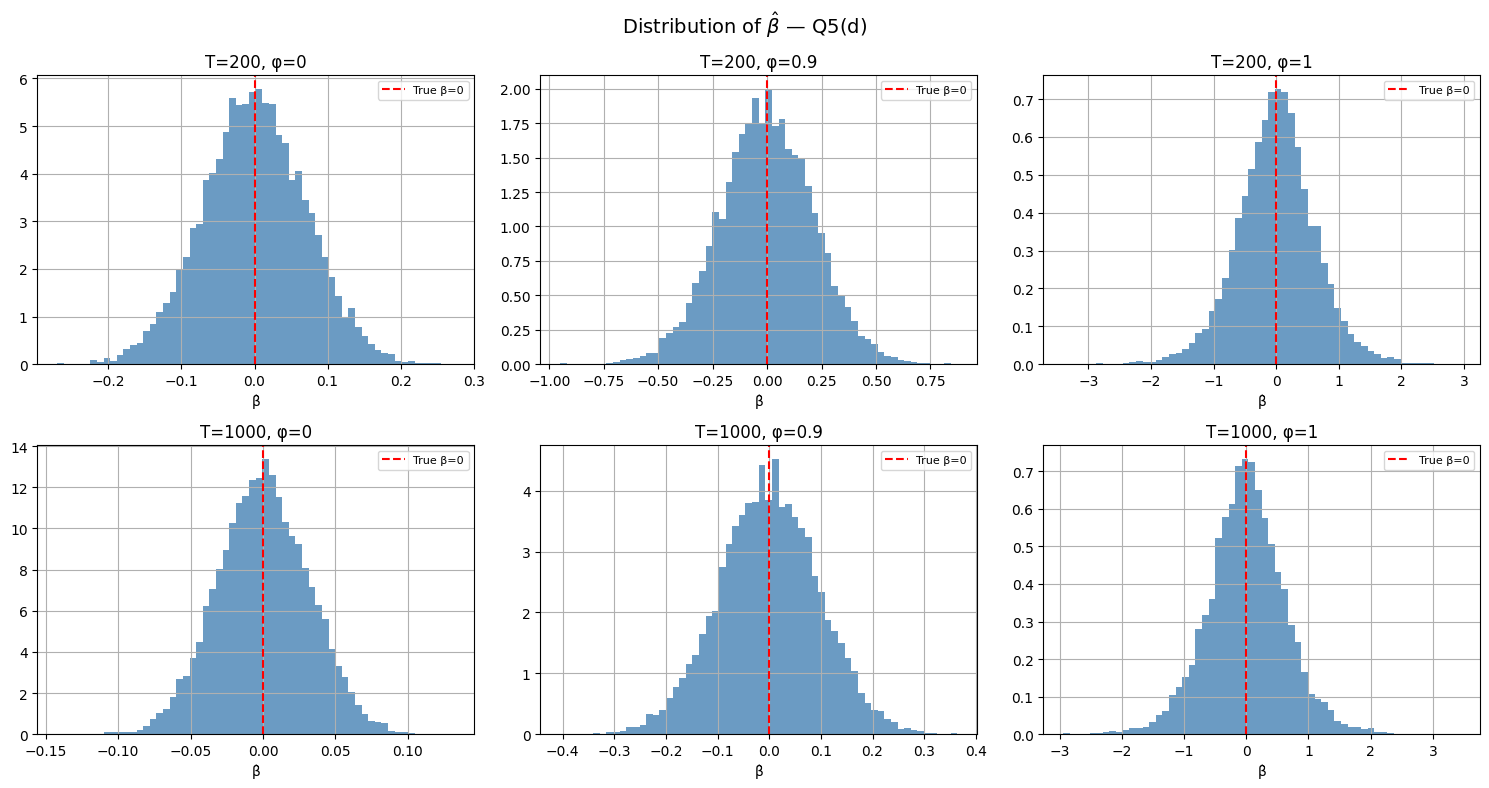

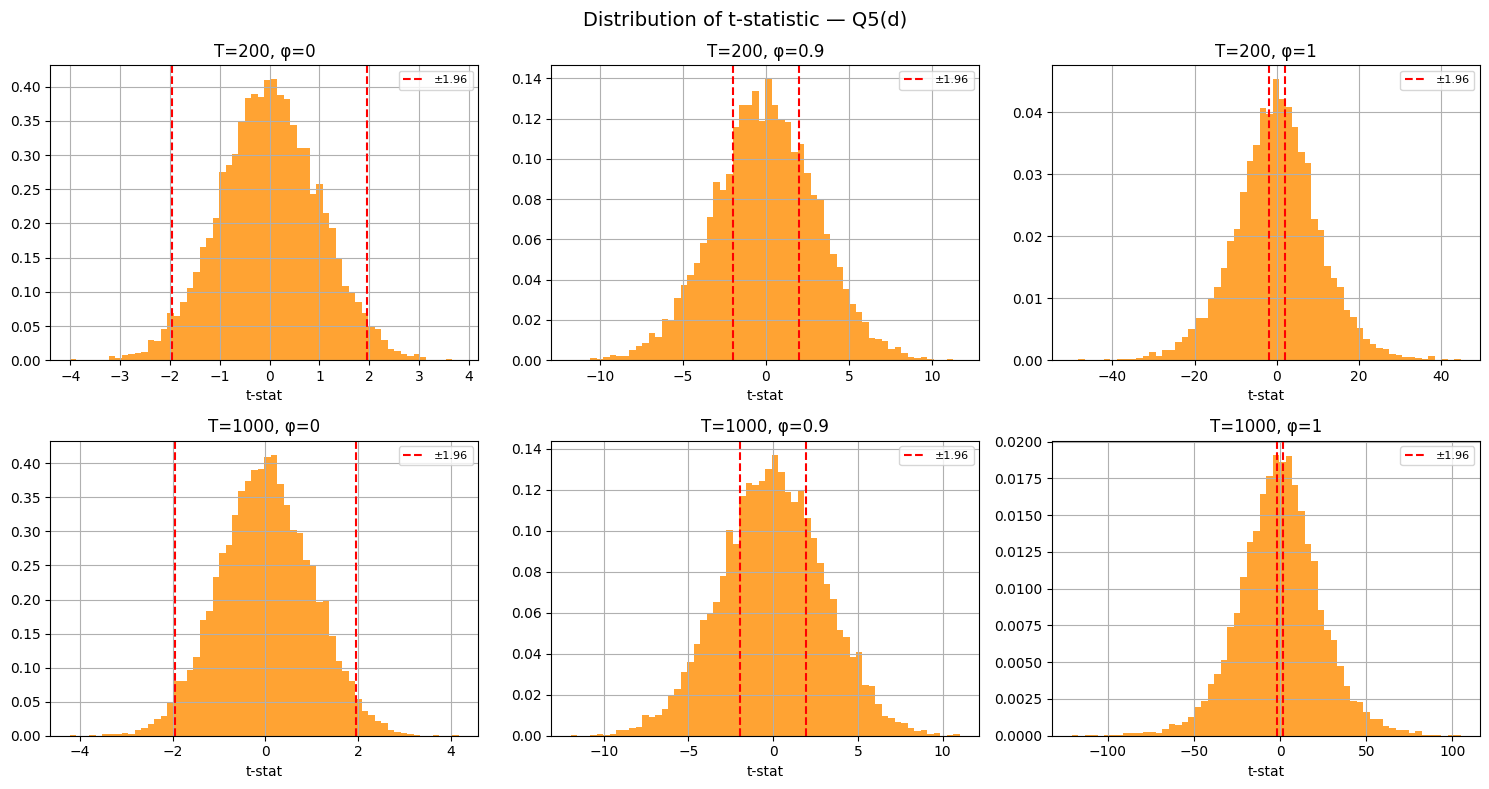

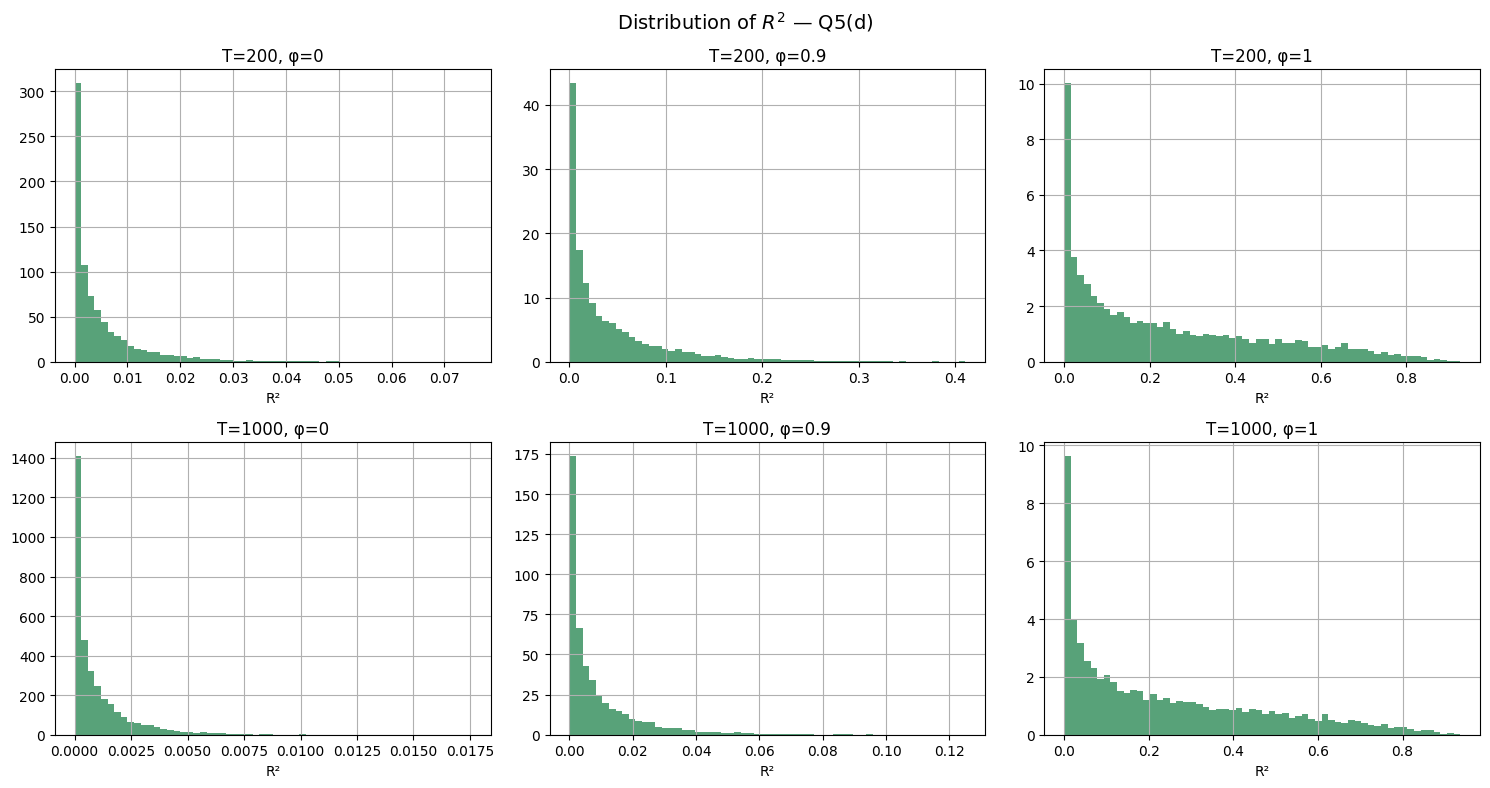

In [29]:
import numpy as np
import matplotlib.pyplot as plt

phis = [0, 0.9, 1]
Ts   = [200, 1000]

fig, axes = plt.subplots(len(Ts), 3, figsize=(15, 8))
fig.suptitle("Distribution of $\\hat{\\beta}$ — Q5(d)", fontsize=14)
for row, T in enumerate(Ts):
    for col, phi in enumerate(phis):
        data = np.array(result[(T, phi)])
        betas = data[:, 1]
        axes[row, col].hist(betas, bins=60, density=True, color="steelblue", alpha=0.8)
        axes[row, col].axvline(0, color="red", linestyle="--", label="True β=0")
        axes[row, col].set_title(f"T={T}, φ={phi}")
        axes[row, col].set_xlabel("β̂")
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(Ts), 3, figsize=(15, 8))
fig.suptitle("Distribution of t-statistic — Q5(d)", fontsize=14)
for row, T in enumerate(Ts):
    for col, phi in enumerate(phis):
        data = np.array(result[(T, phi)])
        tstats = data[:, 3]
        axes[row, col].hist(tstats, bins=60, density=True, color="darkorange", alpha=0.8)
        axes[row, col].axvline(-1.96, color="red", linestyle="--", label="±1.96")
        axes[row, col].axvline( 1.96, color="red", linestyle="--")
        axes[row, col].set_title(f"T={T}, φ={phi}")
        axes[row, col].set_xlabel("t-stat")
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(Ts), 3, figsize=(15, 8))
fig.suptitle("Distribution of $R^2$ — Q5(d)", fontsize=14)
for row, T in enumerate(Ts):
    for col, phi in enumerate(phis):
        data = np.array(result[(T, phi)])
        r2 = data[:, 2]
        axes[row, col].hist(r2, bins=60, density=True, color="seagreen", alpha=0.8)
        axes[row, col].set_title(f"T={T}, φ={phi}")
        axes[row, col].set_xlabel("R²")
        axes[row, col].grid(True)
plt.tight_layout()
plt.show()


In [30]:
# Q5(e) — Rejection rates at 1%, 5%, 10%
from scipy.stats import norm
cv = {0.01: norm.ppf(0.995), 0.05: norm.ppf(0.975), 0.10: norm.ppf(0.95)}

print(f"{'':12} {'φ':>5} {'T':>6} {'1%':>8} {'5%':>8} {'10%':>8}")
print("-" * 55)
for T in [200, 1000]:
    for phi in [0, 0.9, 1]:
        data    = np.array(result[(T, phi)])
        tstats  = data[:, 3]
        rates   = {alpha: np.mean(np.abs(tstats) > c) for alpha, c in cv.items()}
        print(f"{'':12} {phi:>5} {T:>6} {rates[0.01]:>8.3f} {rates[0.05]:>8.3f} {rates[0.10]:>8.3f}")
print()
print("Theoretical correct rejection rates: 1% | 5% | 10%")


                 φ      T       1%       5%      10%
-------------------------------------------------------
                 0    200    0.010    0.052    0.102
               0.9    200    0.399    0.518    0.587
                 1    200    0.782    0.829    0.854
                 0   1000    0.009    0.048    0.101
               0.9   1000    0.396    0.517    0.591
                 1   1000    0.898    0.923    0.935

Theoretical correct rejection rates: 1% | 5% | 10%


## Q5(f) — Interpretation

**φ = 0 (i.i.d. errors):**  
Both x and y are white noise — no serial correlation. OLS is correctly specified. Rejection rates should be close to the nominal levels (1%, 5%, 10%) for all T. β̂ is centered at 0, t-stats follow a standard Normal.

**φ = 0.9 (persistent but stationary AR(1)):**  
Strong serial correlation inflates OLS standard errors (Newey-West adjustment would be needed). The t-test over-rejects significantly — rejection rates far exceed nominal levels. R² is spuriously elevated. The problem worsens with T because the long-run variance grows.

**φ = 1 (random walk — unit root):**  
Classic Granger-Newbold spurious regression. Even though x and y are completely independent, R² does not go to 0 as T→∞ — it converges to a non-degenerate random variable. The t-statistic diverges with T (not bounded), so rejection rates approach 100%. The OLS estimator is inconsistent and t-stats do not follow a Normal or t-distribution under H₀.

**Effect of T:**  
For φ < 1, the spurious rejection problem is present but doesn't worsen with T. For φ = 1, increasing T makes things dramatically worse — rejection rates approach 100% as T grows.
